Variables détectées : ['NDVILandsat5_8', 'SMAP_sm_surface', 'water_S2', 'NDVIS2', 'NDVIMODIS', 'MNDWILandsat', 'MNDWIS2', 'water_Landsat', 'LAIMODIS', 'ERA5_volumetric_soil_water_layer_1']

=== VARIABLES IDENTIFIÉES ===
NDVI Landsat : NDVILandsat5_8
NDVI S2      : NDVIS2
NDVI MODIS   : NDVIMODIS
MNDWI L5     : MNDWILandsat
MNDWI S2     : MNDWIS2
WATER L5     : water_Landsat
WATER S2     : water_S2
ERA5         : ERA5_volumetric_soil_water_layer_1
SMAP         : SMAP_sm_surface



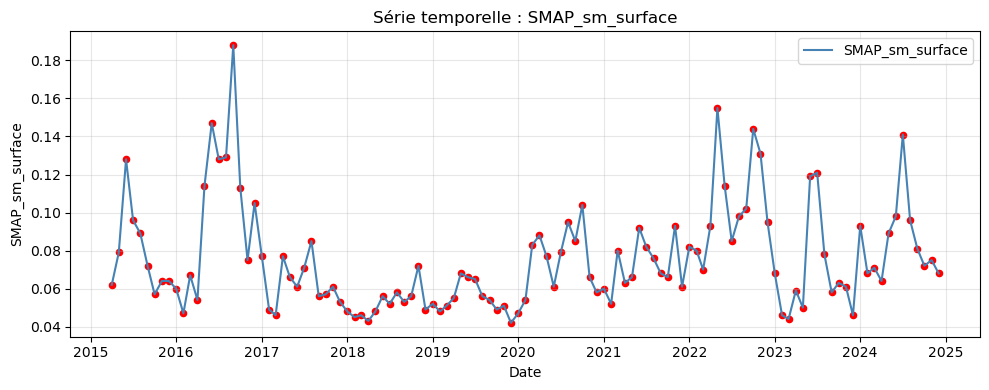

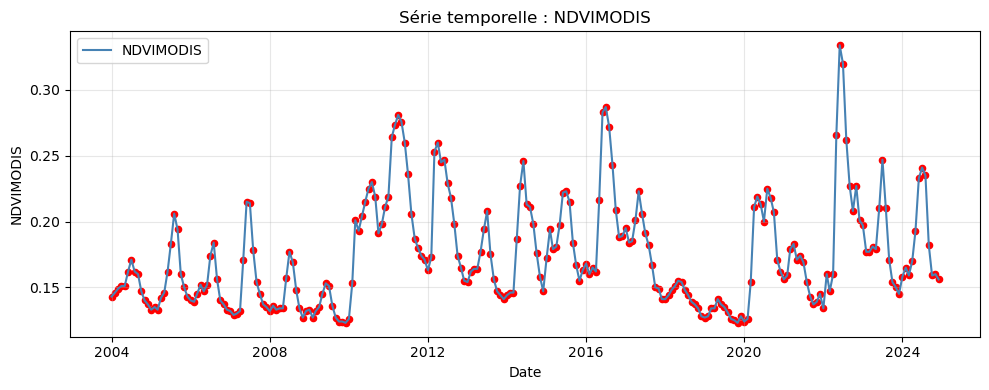

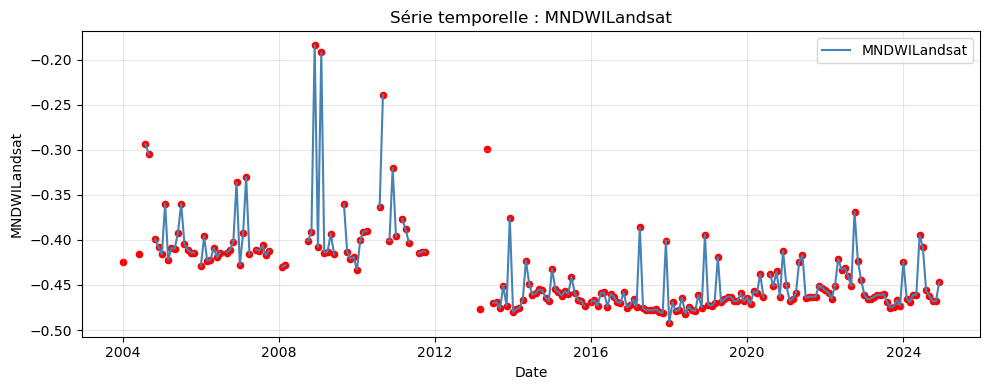

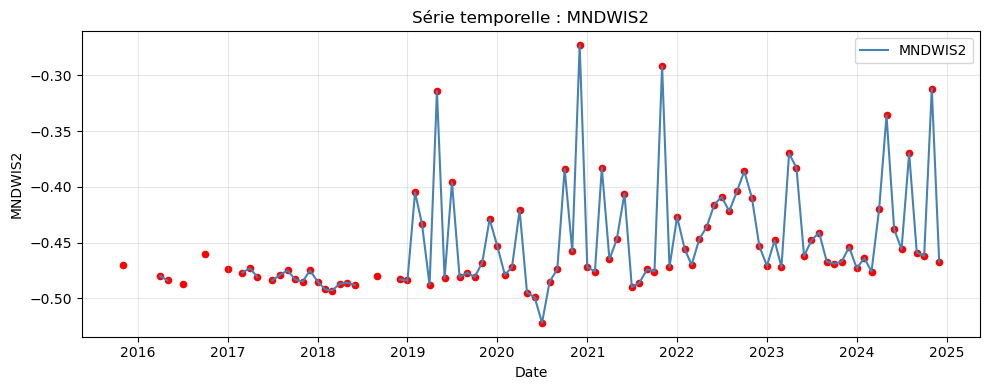

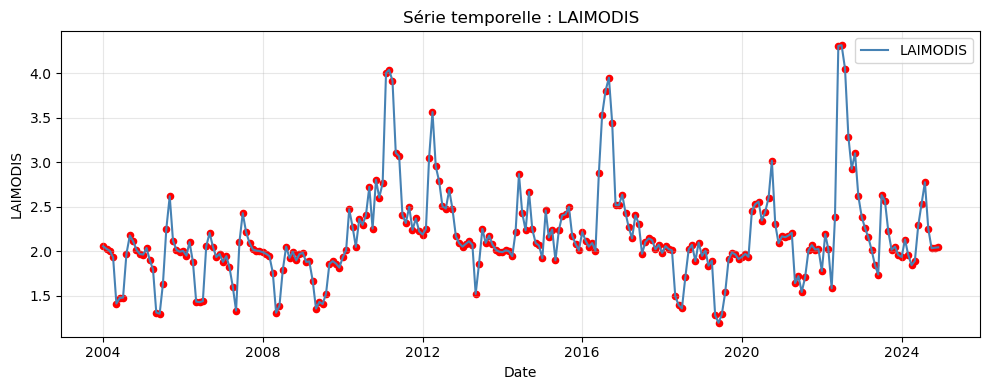

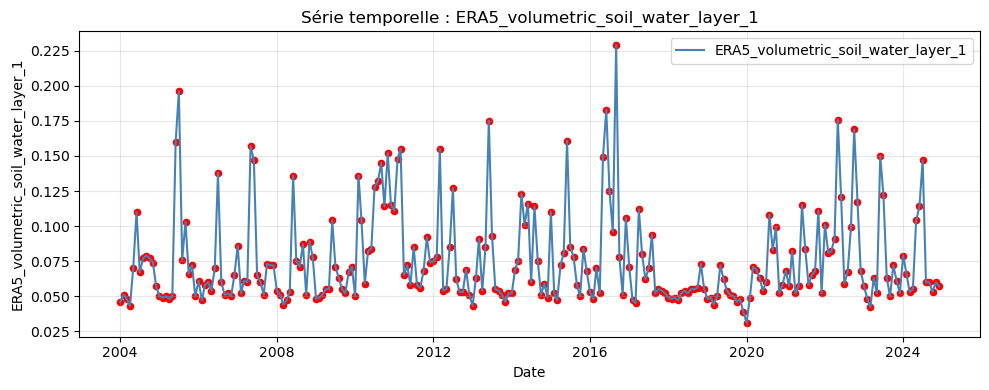

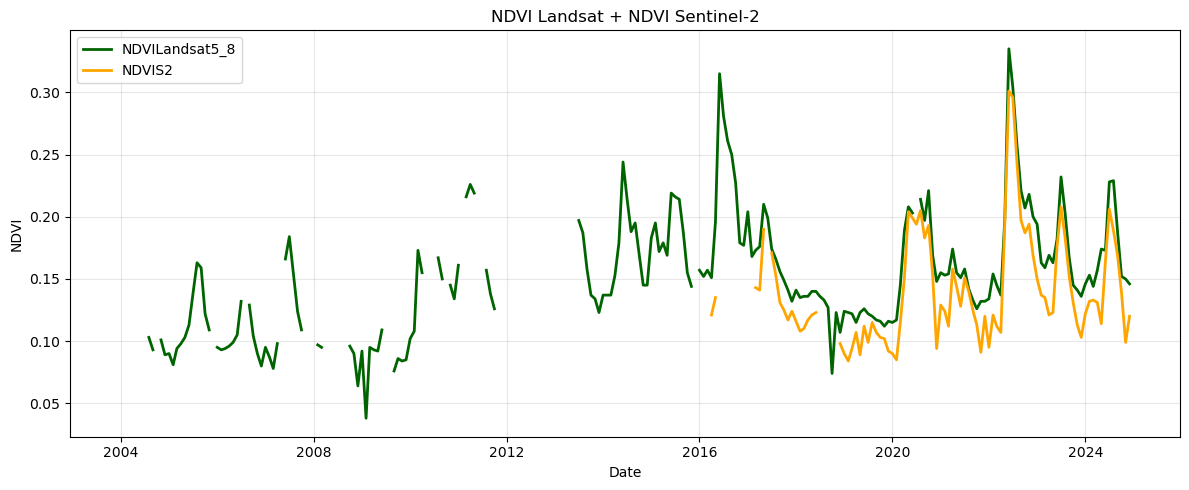

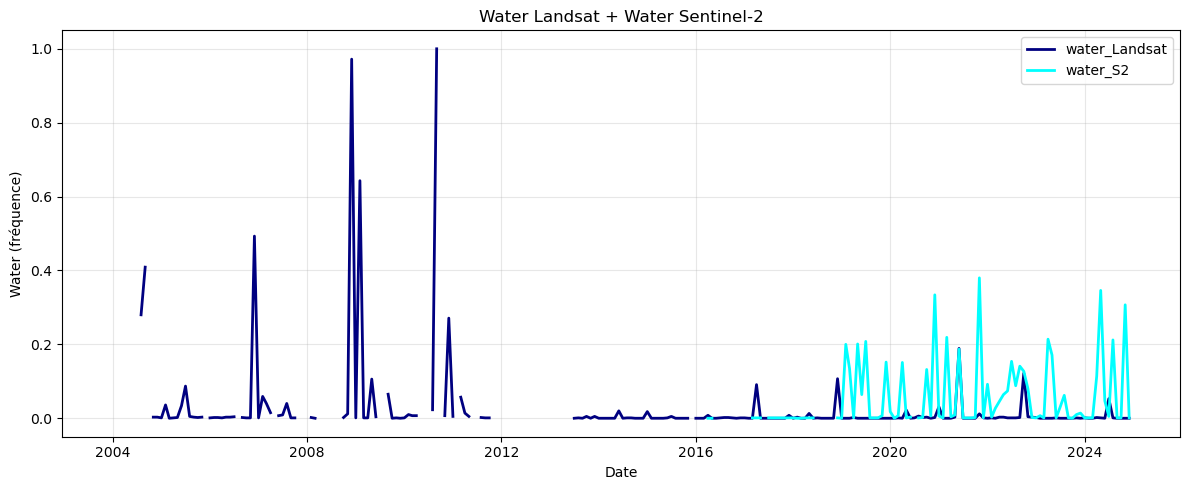

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ---------------------------------------------------------
# 1. Lecture des feuilles csv des séries temporelles
# ---------------------------------------------------------
folder = r"D:\Recherche\PhDdurieux\PhDDureux_ESE2026\csv_temp"
files = sorted(glob.glob(os.path.join(folder, "Feuil*.csv")))

series_frames = {}

for f in files:
    df = pd.read_csv(f)

    # Vérification colonnes
    if df.shape[1] < 2:
        continue

    # Conversion date
    df["date"] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    df = df.dropna(subset=["date"])  

    # Nom de la variable (2e colonne)
    var = df.columns[1]

    # Stockage
    series_frames[var] = df[["date", var]].copy()

print("Variables détectées :", list(series_frames.keys()))

# ---------------------------------------------------------
# 2. IDENTIFICATION AUTOMATIQUE DES VARIABLES
# ---------------------------------------------------------

def find_pair(keyword):
    """Retourne (landsat, s2) pour un mot-clé."""
    l5 = None
    s2 = None
    for var in series_frames:
        v = var.lower()
        if keyword in v:
            if "landsat" in v:
                l5 = var
            elif "s2" in v or "sentinel" in v:
                s2 = var
    return l5, s2

# NDVI Landsat + S2
ndvi_l5, ndvi_s2 = find_pair("ndvi")

# MNDWI Landsat + S2
mndwi_l5, mndwi_s2 = find_pair("mndwi")

# WATER Landsat + S2
water_l5, water_s2 = find_pair("water")

# NDVI MODIS
ndvi_mod = next((v for v in series_frames if "ndvi" in v.lower() and "mod" in v.lower()), None)

# ERA5
era = next((v for v in series_frames if "era5" in v.lower()), None)

# SMAP
smap = next((v for v in series_frames if "smap" in v.lower()), None)

print("\n=== VARIABLES IDENTIFIÉES ===")
print("NDVI Landsat :", ndvi_l5)
print("NDVI S2      :", ndvi_s2)
print("NDVI MODIS   :", ndvi_mod)
print("MNDWI L5     :", mndwi_l5)
print("MNDWI S2     :", mndwi_s2)
print("WATER L5     :", water_l5)
print("WATER S2     :", water_s2)
print("ERA5         :", era)
print("SMAP         :", smap)
print("================================\n")

# ---------------------------------------------------------
# 3. FIGURES INDIVIDUELLES (sauf NDVI et WATER)
# ---------------------------------------------------------
for var, df in series_frames.items():

    # On saute les séries qui seront tracées en duo
    if var in [ndvi_l5, ndvi_s2, water_l5, water_s2]:
        continue

    plt.figure(figsize=(10,4))
    plt.plot(df["date"], df[var], label=var, color="steelblue", linewidth=1.5)
    plt.scatter(df["date"], df[var], color="red", s=20)

    plt.title(f"Série temporelle : {var}")
    plt.xlabel("Date")
    plt.ylabel(var)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 4. FIGURE NDVI : Landsat + Sentinel-2
# ---------------------------------------------------------
if ndvi_l5 or ndvi_s2:
    plt.figure(figsize=(12,5))

    if ndvi_l5:
        df = series_frames[ndvi_l5]
        plt.plot(df["date"], df[ndvi_l5], label=ndvi_l5, color="darkgreen", linewidth=2)

    if ndvi_s2:
        df = series_frames[ndvi_s2]
        plt.plot(df["date"], df[ndvi_s2], label=ndvi_s2, color="orange", linewidth=2)

    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.title("NDVI Landsat + NDVI Sentinel-2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 5. FIGURE WATER : Landsat + Sentinel-2
# ---------------------------------------------------------
if water_l5 or water_s2:
    plt.figure(figsize=(12,5))

    if water_l5:
        df = series_frames[water_l5]
        plt.plot(df["date"], df[water_l5], label=water_l5, color="navy", linewidth=2)

    if water_s2:
        df = series_frames[water_s2]
        plt.plot(df["date"], df[water_s2], label=water_s2, color="cyan", linewidth=2)

    plt.xlabel("Date")
    plt.ylabel("Water (fréquence)")
    plt.title("Water Landsat + Water Sentinel-2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


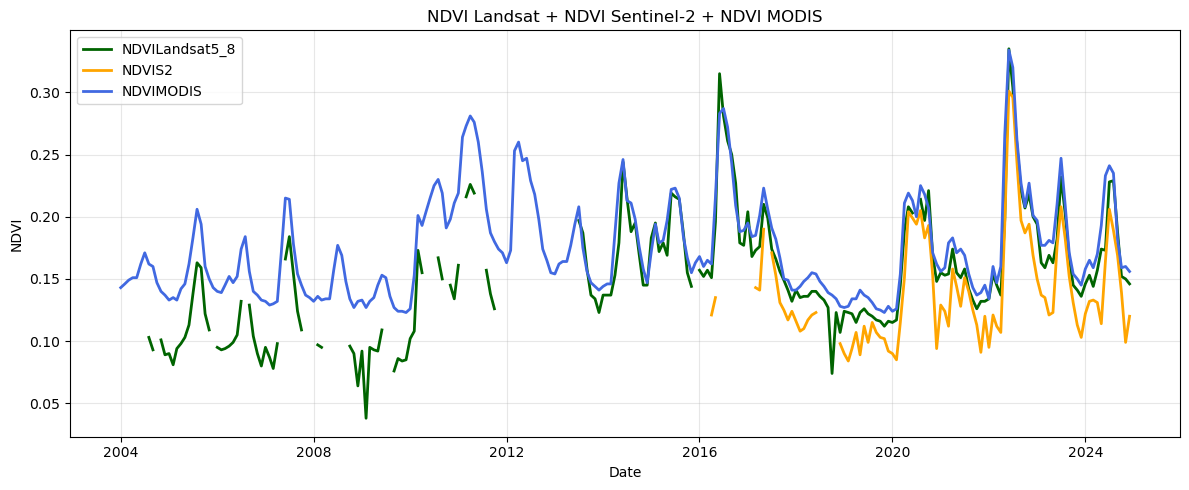

In [4]:
# ---------------------------------------------------------
# 1. FIGURE NDVI : Landsat + Sentinel-2 + MODIS
# ---------------------------------------------------------

plt.figure(figsize=(12,5))

if ndvi_l5:
    df = series_frames[ndvi_l5]
    plt.plot(df["date"], df[ndvi_l5], label=ndvi_l5, color="darkgreen", linewidth=2)

if ndvi_s2:
    df = series_frames[ndvi_s2]
    plt.plot(df["date"], df[ndvi_s2], label=ndvi_s2, color="orange", linewidth=2)

if ndvi_mod:
    df = series_frames[ndvi_mod]
    plt.plot(df["date"], df[ndvi_mod], label=ndvi_mod, color="royalblue", linewidth=2)

plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title("NDVI Landsat + NDVI Sentinel-2 + NDVI MODIS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


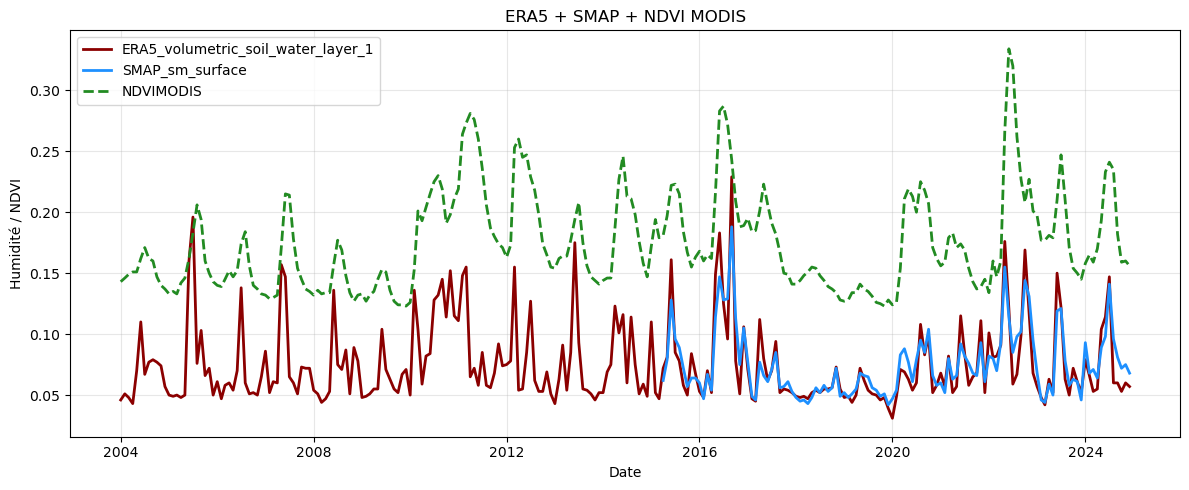

In [5]:
# ---------------------------------------------------------
# 2. FIGURE HUMIDITÉ : ERA5 + SMAP + NDVI MODIS
# ---------------------------------------------------------

plt.figure(figsize=(12,5))

# ERA5
if era:
    df = series_frames[era]
    plt.plot(df["date"], df[era], label=era, color="#8B0000", linewidth=2)

# SMAP
if smap:
    df = series_frames[smap]
    plt.plot(df["date"], df[smap], label=smap, color="#1E90FF", linewidth=2)

# NDVI MODIS
if ndvi_mod:
    df = series_frames[ndvi_mod]
    plt.plot(df["date"], df[ndvi_mod], label=ndvi_mod, color="#228B22", linestyle="--", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Humidité / NDVI")
plt.title("ERA5 + SMAP + NDVI MODIS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


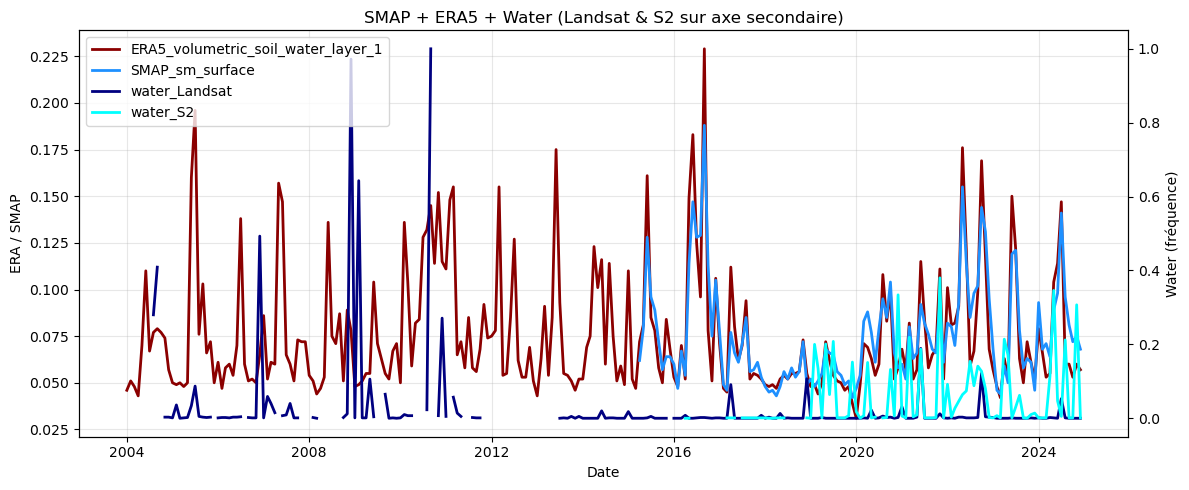

In [6]:
# ---------------------------------------------------------
# 3. FIGURE SMAP + ERA5 + WATER (axe secondaire)
# ---------------------------------------------------------

plt.figure(figsize=(12,5))
ax1 = plt.gca()

# ERA5
if era:
    df = series_frames[era]
    ax1.plot(df["date"], df[era], label=era, color="#8B0000", linewidth=2)

# SMAP
if smap:
    df = series_frames[smap]
    ax1.plot(df["date"], df[smap], label=smap, color="#1E90FF", linewidth=2)

ax1.set_xlabel("Date")
ax1.set_ylabel("ERA / SMAP")
ax1.grid(True, alpha=0.3)

# Axe secondaire : WATER
ax2 = ax1.twinx()

if water_l5:
    df = series_frames[water_l5]
    ax2.plot(df["date"], df[water_l5], label=water_l5, color="navy", linewidth=2)

if water_s2:
    df = series_frames[water_s2]
    ax2.plot(df["date"], df[water_s2], label=water_s2, color="cyan", linewidth=2)

ax2.set_ylabel("Water (fréquence)")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("SMAP + ERA5 + Water (Landsat & S2 sur axe secondaire)")
plt.tight_layout()
plt.show()


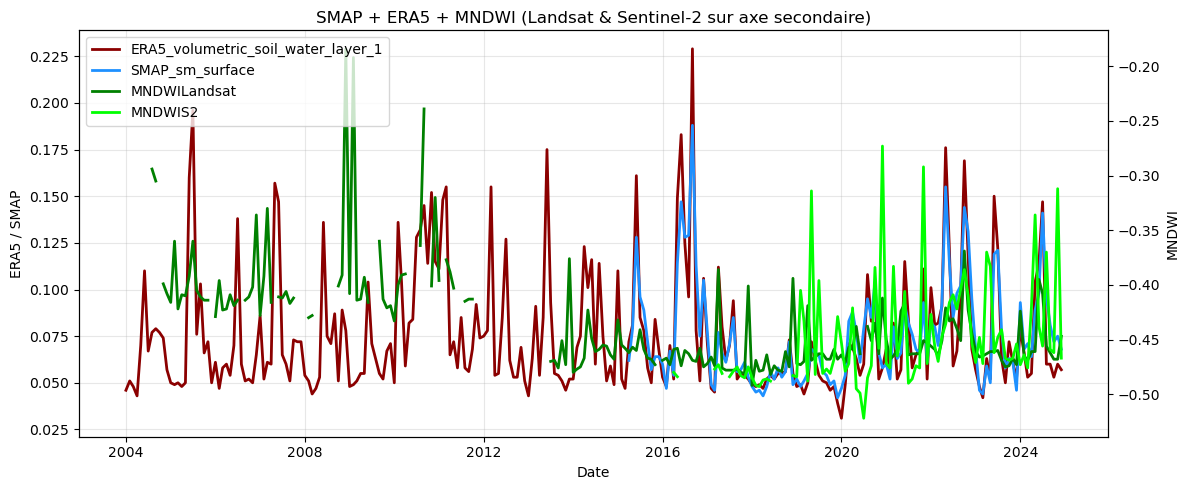

In [7]:
# ---------------------------------------------------------
# FIGURE SMAP + ERA5 + MNDWI (axe secondaire)
# ---------------------------------------------------------

plt.figure(figsize=(12,5))
ax1 = plt.gca()

# ERA5
if era:
    df = series_frames[era]
    ax1.plot(df["date"], df[era], label=era, color="#8B0000", linewidth=2)  # Rouge foncé

# SMAP
if smap:
    df = series_frames[smap]
    ax1.plot(df["date"], df[smap], label=smap, color="#1E90FF", linewidth=2)  # Bleu vif

ax1.set_xlabel("Date")
ax1.set_ylabel("ERA5 / SMAP")
ax1.grid(True, alpha=0.3)

# Axe secondaire : MNDWI
ax2 = ax1.twinx()

if mndwi_l5:
    df = series_frames[mndwi_l5]
    ax2.plot(df["date"], df[mndwi_l5], label=mndwi_l5, color="green", linewidth=2)

if mndwi_s2:
    df = series_frames[mndwi_s2]
    ax2.plot(df["date"], df[mndwi_s2], label=mndwi_s2, color="lime", linewidth=2)

ax2.set_ylabel("MNDWI")

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("SMAP + ERA5 + MNDWI (Landsat & Sentinel-2 sur axe secondaire)")
plt.tight_layout()
plt.show()



===== MATRICE DE CORRÉLATION =====

                                    NDVILandsat5_8  SMAP_sm_surface  water_S2  \
NDVILandsat5_8                            1.000000         0.673204  0.055975   
SMAP_sm_surface                           0.673204         1.000000  0.153074   
water_S2                                  0.055975         0.153074  1.000000   
NDVIS2                                    0.954364         0.648560 -0.111066   
NDVIMODIS                                 0.967409         0.711977  0.076205   
MNDWILandsat                              0.260296         0.472044  0.143581   
MNDWIS2                                   0.125829         0.240362  0.941944   
water_Landsat                             0.016396         0.212359  0.097631   
LAIMODIS                                  0.867972         0.501824  0.033474   
ERA5_volumetric_soil_water_layer_1        0.499729         0.893888  0.143869   

                                      NDVIS2  NDVIMODIS  MNDWILandsat  

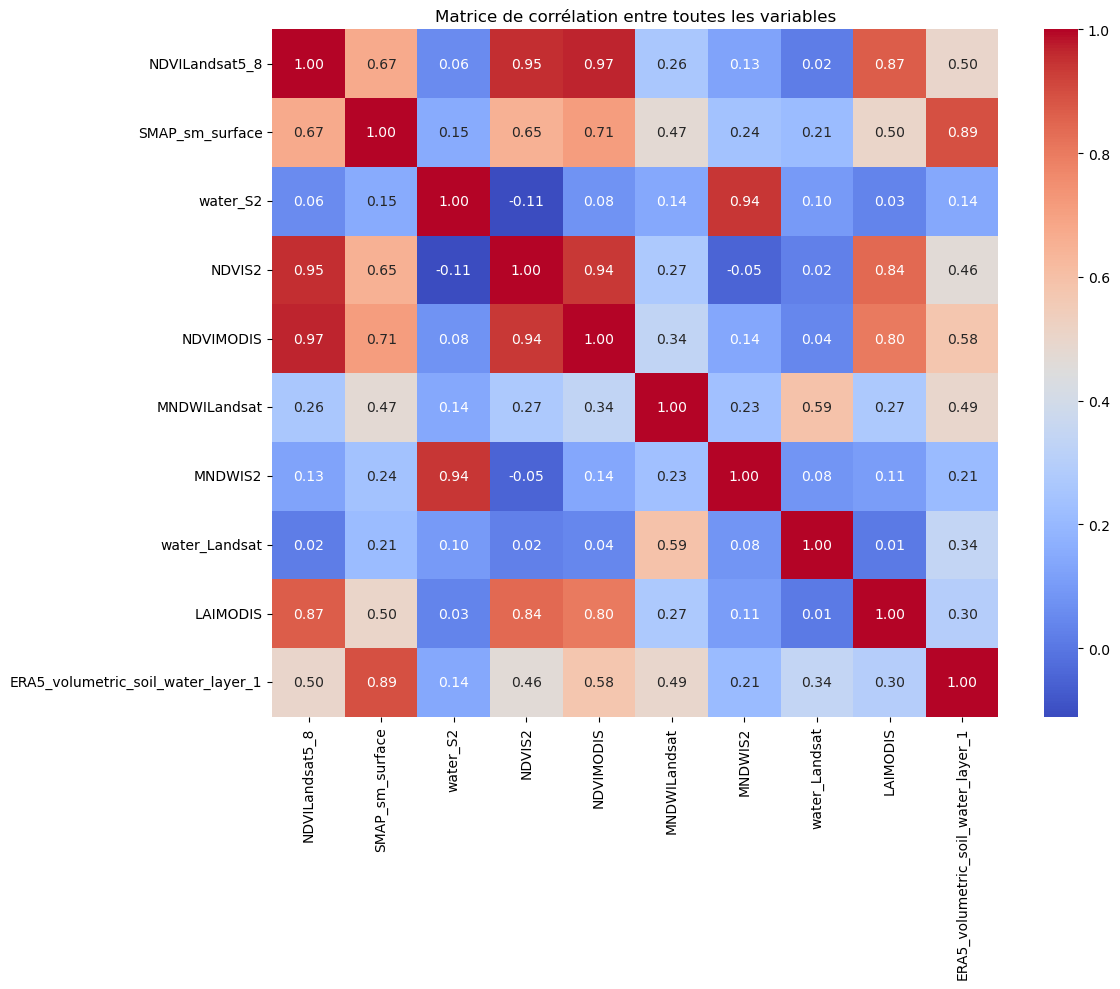

In [8]:
# ---------------------------------------------------------
# MATRICE DE CORRÉLATION POUR TOUTES LES VARIABLES
# (WATER : exclusion des valeurs nulles)
# ---------------------------------------------------------

# 1. Fusionner toutes les séries temporelles dans un seul DataFrame
merged = None

for var, df in series_frames.items():
    temp = df.rename(columns={var: var})
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on="date", how="outer")

# 2. Exclure les valeurs nulles uniquement pour WATER
water_vars = [v for v in [water_l5, water_s2] if v is not None]

if water_vars:
    for w in water_vars:
        merged = merged[merged[w].notna()]

# 3. Supprimer la colonne date pour la corrélation
corr_df = merged.drop(columns=["date"])

# 4. Calcul de la matrice de corrélation
corr_matrix = corr_df.corr()

print("\n===== MATRICE DE CORRÉLATION =====\n")
print(corr_matrix)

# 5. (OPTIONNEL) Heatmap
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation entre toutes les variables")
plt.tight_layout()
plt.show()


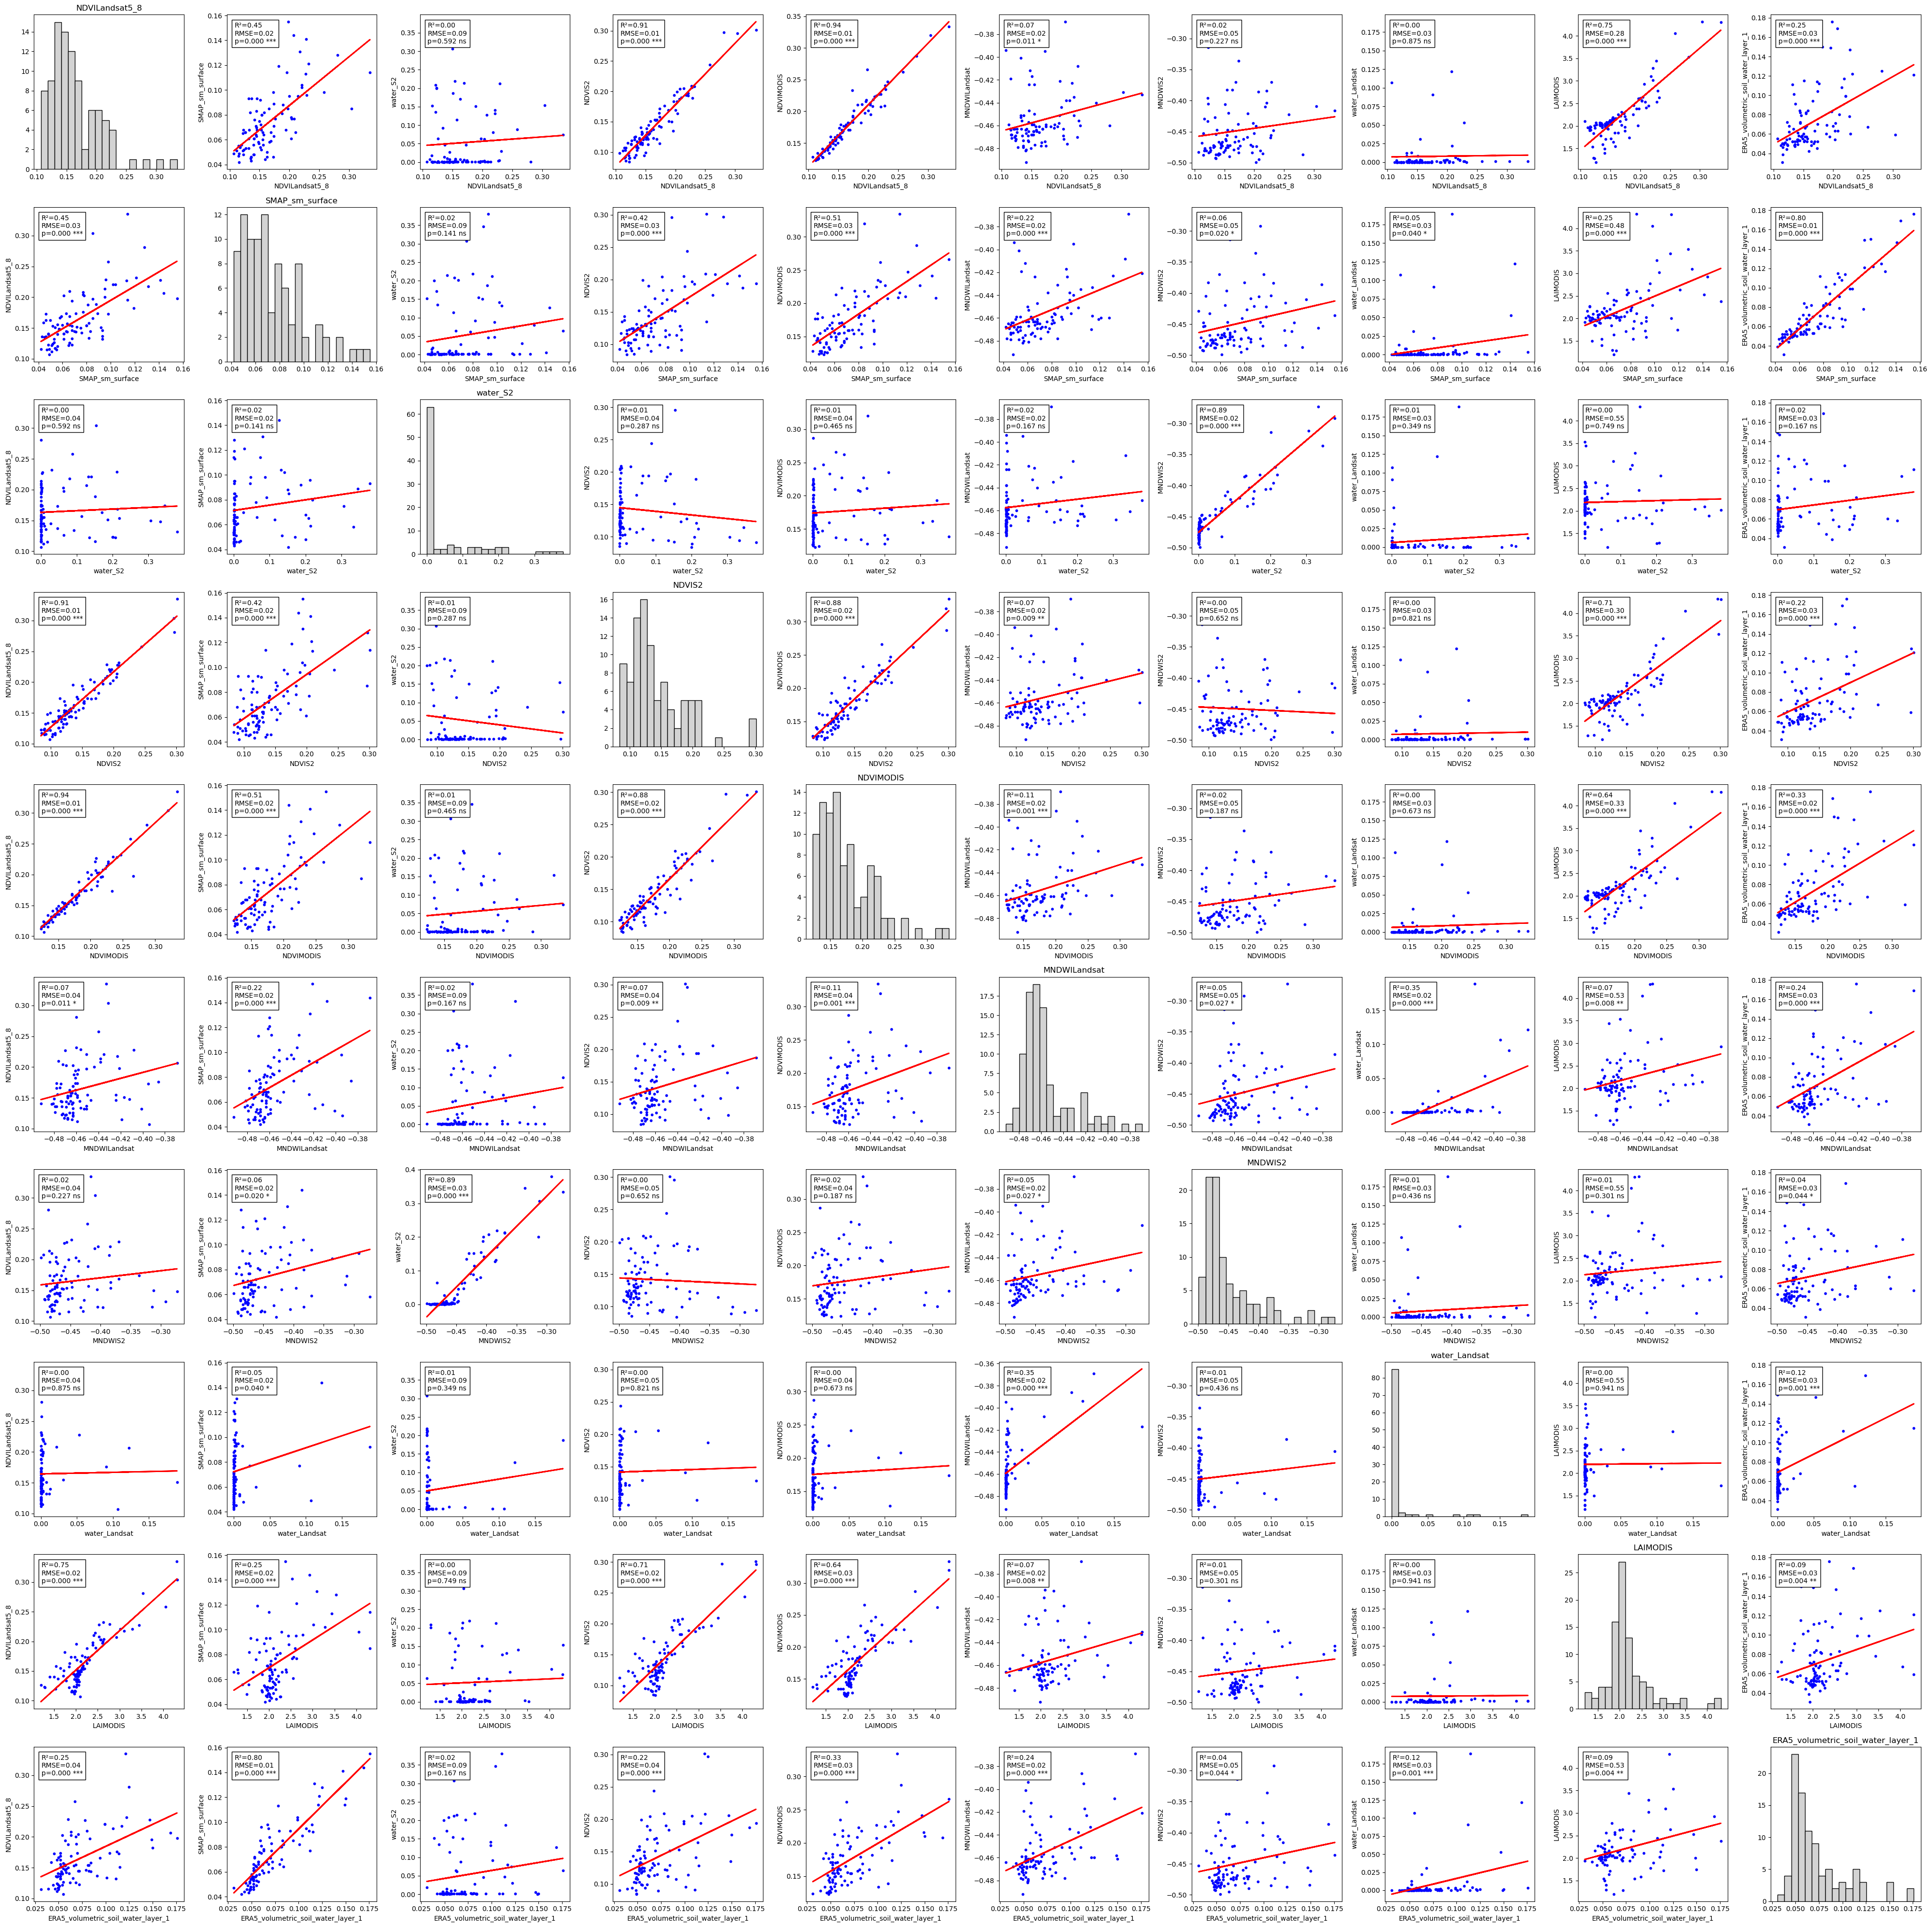

In [9]:
# ---------------------------------------------------------
# MATRICE DE SCATTERPLOTS AVEC R2, RMSE, P ET DROITE DE RÉGRESSION
# ---------------------------------------------------------

import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Fusionner toutes les séries dans un seul DataFrame
merged = None
for var, df in series_frames.items():
    temp = df.rename(columns={var: var})
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on="date", how="outer")

# 2. Exclure valeurs nulles uniquement pour WATER
water_vars = [v for v in [water_l5, water_s2] if v is not None]
for w in water_vars:
    merged = merged[merged[w].notna()]

# 3. Retirer la colonne date
data = merged.drop(columns=["date"]).copy()

# 4. Fonction pour notation p-value
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# 5. Création de la matrice de scatterplots
vars_list = data.columns
n = len(vars_list)

fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

for i, var_x in enumerate(vars_list):
    for j, var_y in enumerate(vars_list):

        ax = axes[i, j]

        # Diagonale : histogramme
        if i == j:
            ax.hist(data[var_x].dropna(), bins=20, color="lightgray", edgecolor="black")
            ax.set_title(var_x)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_frame_on(True)
            continue

        # Scatterplot
        x = data[var_x]
        y = data[var_y]

        # Exclure lignes où x ou y est NaN
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]

        ax.scatter(x, y, color="blue", s=10)

        # Régression linéaire
        if len(x) > 2:
            slope, intercept, r, p, stderr = stats.linregress(x, y)
            y_pred = slope * x + intercept
            rmse = np.sqrt(np.mean((y - y_pred)**2))
            r2 = r**2

            # Droite de régression
            ax.plot(x, y_pred, color="red", linewidth=2)

            # Texte statistique
            text = f"R²={r2:.2f}\nRMSE={rmse:.2f}\np={p:.3f} {p_to_stars(p)}"
            ax.text(0.05, 0.95, text, transform=ax.transAxes,
                    fontsize=10, verticalalignment="top",
                    bbox=dict(facecolor="white", edgecolor="black"))

        ax.set_xlabel(var_x)
        ax.set_ylabel(var_y)
        ax.set_frame_on(True)

plt.tight_layout()
plt.show()


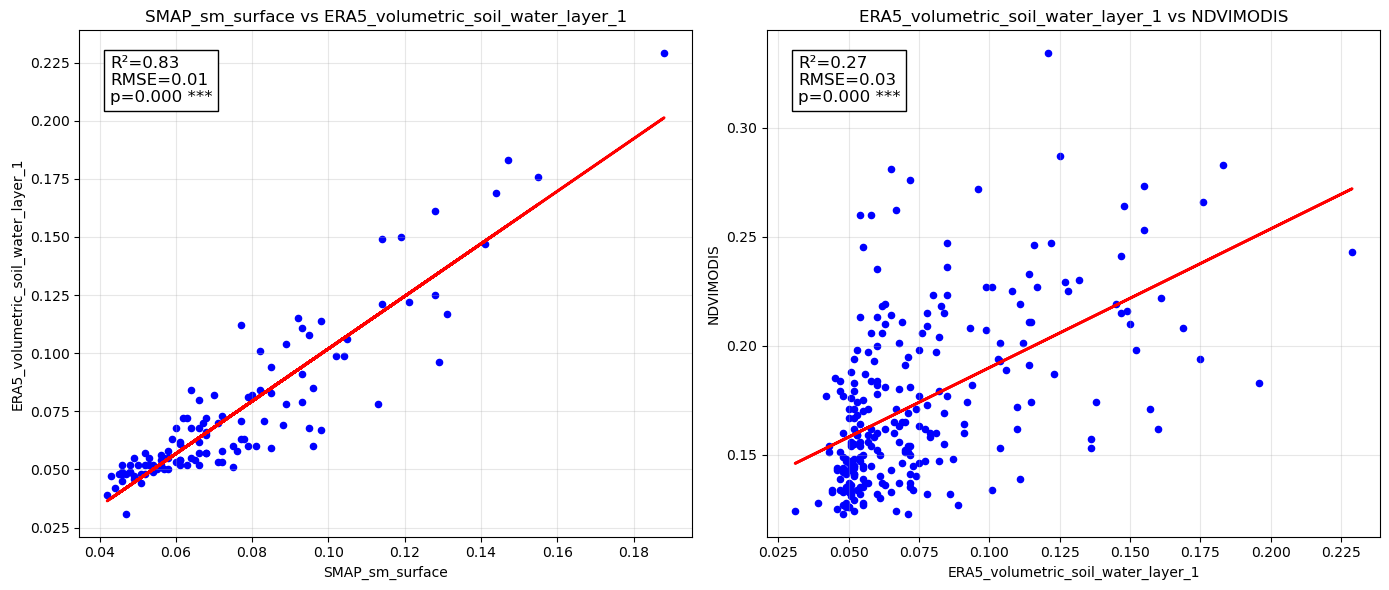

In [13]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Fonction utilitaire : notation p-value
# ---------------------------------------------------------
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# ---------------------------------------------------------
# Fusionner toutes les séries sans filtrage WATER
# ---------------------------------------------------------
merged = None
for var, df in series_frames.items():
    temp = df.rename(columns={var: var})
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on="date", how="outer")

# ---------------------------------------------------------
# FIGURE : deux scatterplots sur une même ligne
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# 1. SMAP vs ERA5
# ---------------------------------------------------------
if smap and era:
    ax = axes[0]

    x = merged[smap]
    y = merged[era]

    # Filtrer uniquement les NaN des deux variables
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, color="blue", s=20)

    # Régression
    slope, intercept, r, p, stderr = stats.linregress(x, y)
    y_pred = slope * x + intercept
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    r2 = r**2

    ax.plot(x, y_pred, color="red", linewidth=2)

    # Texte stats
    txt = f"R²={r2:.2f}\nRMSE={rmse:.2f}\np={p:.3f} {p_to_stars(p)}"
    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            fontsize=12, verticalalignment="top",
            bbox=dict(facecolor="white", edgecolor="black"))

    ax.set_xlabel(smap)
    ax.set_ylabel(era)
    ax.set_title(f"{smap} vs {era}")
    ax.grid(True, alpha=0.3)
    ax.set_frame_on(True)

# ---------------------------------------------------------
# 2. ERA5 vs NDVI MODIS
# ---------------------------------------------------------
if era and ndvi_mod:
    ax = axes[1]

    x = merged[era]
    y = merged[ndvi_mod]

    # Filtrer uniquement les NaN des deux variables
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, color="blue", s=20)

    # Régression
    slope, intercept, r, p, stderr = stats.linregress(x, y)
    y_pred = slope * x + intercept
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    r2 = r**2

    ax.plot(x, y_pred, color="red", linewidth=2)

    # Texte stats
    txt = f"R²={r2:.2f}\nRMSE={rmse:.2f}\np={p:.3f} {p_to_stars(p)}"
    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            fontsize=12, verticalalignment="top",
            bbox=dict(facecolor="white", edgecolor="black"))

    ax.set_xlabel(era)
    ax.set_ylabel(ndvi_mod)
    ax.set_title(f"{era} vs {ndvi_mod}")
    ax.grid(True, alpha=0.3)
    ax.set_frame_on(True)

plt.tight_layout()
plt.show()



>>> Lag optimal = -1 pas de temps
>>> Corrélation maximale = 0.606



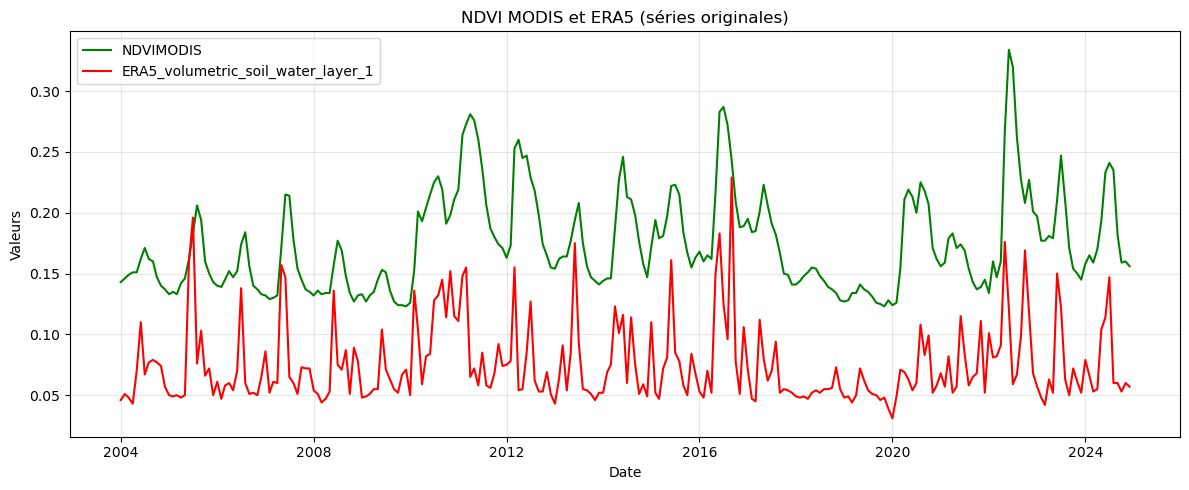

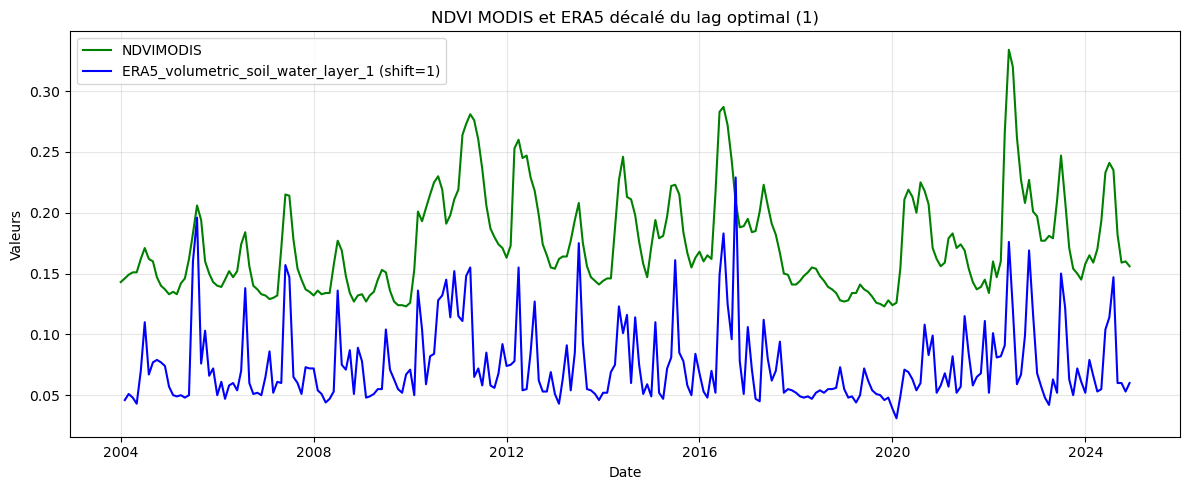

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Fusionner toutes les séries SANS filtrage WATER
# ---------------------------------------------------------
merged = None
for var, df in series_frames.items():
    temp = df.rename(columns={var: var})
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on="date", how="outer")

# ---------------------------------------------------------
# 2. Extraction NDVI_MODIS et ERA5
# ---------------------------------------------------------
if ndvi_mod is None or era is None:
    print("NDVI_MODIS ou ERA5 introuvable.")
else:
    x = merged[ndvi_mod]
    y = merged[era]

    # Exclure uniquement les NaN des deux séries
    mask = x.notna() & y.notna()
    x = x[mask].reset_index(drop=True)
    y = y[mask].reset_index(drop=True)

    # ---------------------------------------------------------
    # 3. CROSS-CORRELATION
    # ---------------------------------------------------------
    def cross_corr(a, b, max_lag=60):
        """Retourne la cross-corrélation pour des lags de -max_lag à +max_lag."""
        lags = np.arange(-max_lag, max_lag+1)
        corr = []
        for lag in lags:
            if lag < 0:
                corr.append(np.corrcoef(a[-lag:], b[:lag])[0,1])
            elif lag > 0:
                corr.append(np.corrcoef(a[:-lag], b[lag:])[0,1])
            else:
                corr.append(np.corrcoef(a, b)[0,1])
        return lags, np.array(corr)

    lags, corr = cross_corr(x.values, y.values, max_lag=60)

    # Lag optimal
    best_lag = lags[np.nanargmax(np.abs(corr))]
    best_corr = corr[np.nanargmax(np.abs(corr))]

    print(f"\n>>> Lag optimal = {best_lag} pas de temps")
    print(f">>> Corrélation maximale = {best_corr:.3f}\n")

    # ---------------------------------------------------------
    # 4. FIGURE 1 : Séries originales
    # ---------------------------------------------------------
    plt.figure(figsize=(12,5))
    plt.plot(merged["date"], merged[ndvi_mod], label=ndvi_mod, color="green")
    plt.plot(merged["date"], merged[era], label=era, color="red")
    plt.title("NDVI MODIS et ERA5 (séries originales)")
    plt.xlabel("Date")
    plt.ylabel("Valeurs")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 5. FIGURE 2 : NDVI_MODIS et ERA5 décalé du lag optimal
    # ---------------------------------------------------------
    shifted = merged[era].shift(-best_lag)

    plt.figure(figsize=(12,5))
    plt.plot(merged["date"], merged[ndvi_mod], label=ndvi_mod, color="green")
    plt.plot(merged["date"], shifted, label=f"{era} (shift={-best_lag})", color="blue")
    plt.title(f"NDVI MODIS et ERA5 décalé du lag optimal ({-best_lag})")
    plt.xlabel("Date")
    plt.ylabel("Valeurs")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



>>> Lag optimal = -1 pas de temps
>>> Corrélation maximale = 0.606



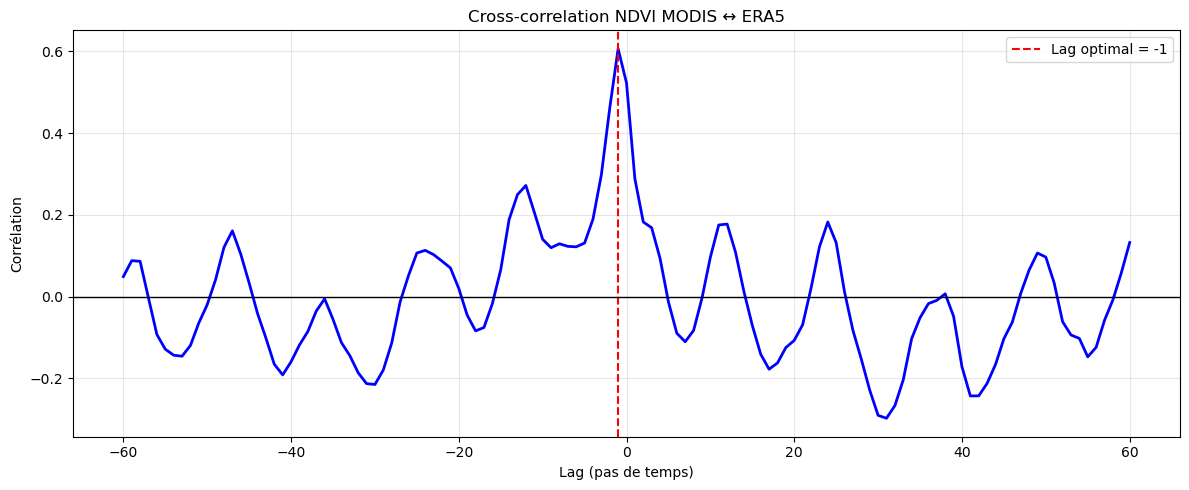

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Fusionner toutes les séries SANS filtrage WATER
# ---------------------------------------------------------
merged = None
for var, df in series_frames.items():
    temp = df.rename(columns={var: var})
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on="date", how="outer")

# ---------------------------------------------------------
# 2. Extraction NDVI_MODIS et ERA5
# ---------------------------------------------------------
if ndvi_mod is None or era is None:
    print("NDVI_MODIS ou ERA5 introuvable.")
else:
    x = merged[ndvi_mod]
    y = merged[era]

    # Exclure uniquement les NaN des deux séries
    mask = x.notna() & y.notna()
    x = x[mask].reset_index(drop=True)
    y = y[mask].reset_index(drop=True)

    # ---------------------------------------------------------
    # 3. CROSS-CORRELATION
    # ---------------------------------------------------------
    def cross_corr(a, b, max_lag=60):
        """Retourne la cross-corrélation pour des lags de -max_lag à +max_lag."""
        lags = np.arange(-max_lag, max_lag+1)
        corr = []
        for lag in lags:
            if lag < 0:
                corr.append(np.corrcoef(a[-lag:], b[:lag])[0,1])
            elif lag > 0:
                corr.append(np.corrcoef(a[:-lag], b[lag:])[0,1])
            else:
                corr.append(np.corrcoef(a, b)[0,1])
        return lags, np.array(corr)

    lags, corr = cross_corr(x.values, y.values, max_lag=60)

    # Lag optimal
    best_lag = lags[np.nanargmax(np.abs(corr))]
    best_corr = corr[np.nanargmax(np.abs(corr))]

    print(f"\n>>> Lag optimal = {best_lag} pas de temps")
    print(f">>> Corrélation maximale = {best_corr:.3f}\n")

    # ---------------------------------------------------------
    # 4. COURBE DE CROSS-CORRELATION
    # ---------------------------------------------------------
    plt.figure(figsize=(12,5))
    plt.plot(lags, corr, color="blue", linewidth=2)
    plt.axvline(best_lag, color="red", linestyle="--", label=f"Lag optimal = {best_lag}")
    plt.axhline(0, color="black", linewidth=1)

    plt.title("Cross-correlation NDVI MODIS ↔ ERA5")
    plt.xlabel("Lag (pas de temps)")
    plt.ylabel("Corrélation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



>>> Lag optimal (Spearman) = -1 pas de temps
>>> Corrélation maximale (Spearman) = 0.562



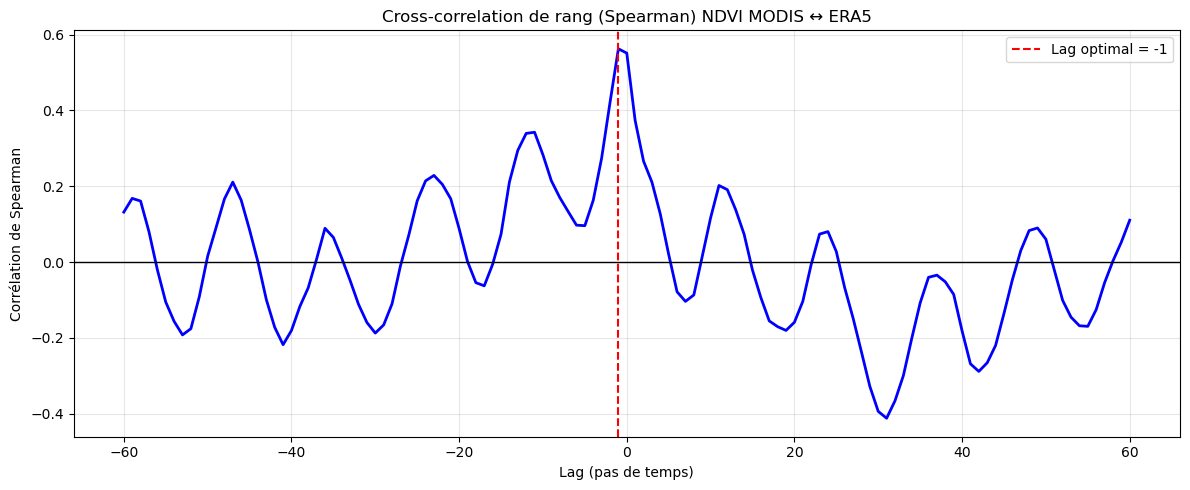

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ---------------------------------------------------------
# 1. Fusionner toutes les séries SANS filtrage WATER
# ---------------------------------------------------------
merged = None
for var, df in series_frames.items():
    temp = df.rename(columns={var: var})
    if merged is None:
        merged = temp
    else:
        merged = pd.merge(merged, temp, on="date", how="outer")

# ---------------------------------------------------------
# 2. Extraction NDVI_MODIS et ERA5
# ---------------------------------------------------------
if ndvi_mod is None or era is None:
    print("NDVI_MODIS ou ERA5 introuvable.")
else:
    x = merged[ndvi_mod]
    y = merged[era]

    # Exclure uniquement les NaN des deux séries
    mask = x.notna() & y.notna()
    x = x[mask].reset_index(drop=True)
    y = y[mask].reset_index(drop=True)

    # ---------------------------------------------------------
    # 3. CROSS-CORRELATION DE SPEARMAN
    # ---------------------------------------------------------
    def cross_corr_spearman(a, b, max_lag=60):
        """Cross-correlation basée sur Spearman pour lags -max_lag à +max_lag."""
        lags = np.arange(-max_lag, max_lag+1)
        corr = []

        for lag in lags:
            if lag < 0:
                rho, _ = spearmanr(a[-lag:], b[:lag])
            elif lag > 0:
                rho, _ = spearmanr(a[:-lag], b[lag:])
            else:
                rho, _ = spearmanr(a, b)
            corr.append(rho)

        return lags, np.array(corr)

    lags, corr = cross_corr_spearman(x.values, y.values, max_lag=60)

    # Lag optimal
    best_lag = lags[np.nanargmax(np.abs(corr))]
    best_corr = corr[np.nanargmax(np.abs(corr))]

    print(f"\n>>> Lag optimal (Spearman) = {best_lag} pas de temps")
    print(f">>> Corrélation maximale (Spearman) = {best_corr:.3f}\n")

    # ---------------------------------------------------------
    # 4. COURBE DE CROSS-CORRELATION DE RANG
    # ---------------------------------------------------------
    plt.figure(figsize=(12,5))
    plt.plot(lags, corr, color="blue", linewidth=2)
    plt.axvline(best_lag, color="red", linestyle="--", label=f"Lag optimal = {best_lag}")
    plt.axhline(0, color="black", linewidth=1)

    plt.title("Cross-correlation de rang (Spearman) NDVI MODIS ↔ ERA5")
    plt.xlabel("Lag (pas de temps)")
    plt.ylabel("Corrélation de Spearman")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
